> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 3. The Python Machine Learning Stack

*Scope:* The four libraries every later chapter imports, and the scikit-learn API contract that every estimator in this material obeys.

Four libraries carry almost all the code in this material, and they divide the work cleanly:

| Library | Owns | Data structure |
|---|---|---|
| **NumPy** | Numerical arrays and the arithmetic on them | `ndarray` — one dtype, n-dimensional |
| **pandas** | Labelled, mixed-type tabular data; cleaning and reshaping | `DataFrame` — named columns, each its own dtype |
| **matplotlib** / **seaborn** | Looking at the data | Figures and axes |
| **scikit-learn** | Models, transformers, evaluation, and the API that unifies them | Estimators consuming NumPy arrays or DataFrames |

The usual flow is pandas for loading and cleaning, NumPy underneath everything, matplotlib to see what you
have, and scikit-learn to model it. This chapter covers the parts of each that the rest of the material
actually uses — not a full tour.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.width", 100)

print("numpy ", np.__version__)
print("pandas", pd.__version__)

numpy  2.5.2
pandas 3.0.5


### 3.1 NumPy: the ndarray

A Python list holds pointers to arbitrary objects scattered through memory. A NumPy **ndarray** holds raw
values of one type in one contiguous block. That single difference is what makes array arithmetic fast, and
it is why every ML library uses arrays rather than lists underneath.

#### 3.1.1 Creation, dtype and shape

| Attribute | Meaning |
|---|---|
| `.shape` | Size along each dimension, as a tuple |
| `.ndim` | Number of dimensions (`len(shape)`) |
| `.dtype` | The single type every element has |
| `.size` | Total number of elements |
| `.nbytes` | Memory used by the data itself |

In [2]:
arr = np.array([[1, 2, 3],
                [4, 5, 6]])

print("shape ", arr.shape)     # (2, 3)
print("ndim  ", arr.ndim)      # 2
print("dtype ", arr.dtype)     # int64
print("size  ", arr.size)      # 6
print("nbytes", arr.nbytes)    # 48 -> 6 elements x 8 bytes

shape  (2, 3)
ndim   2
dtype  int64
size   6
nbytes 48


The constructors used throughout this material:

In [3]:
print("zeros    ", np.zeros(3))                        # [0. 0. 0.]
print("ones     ", np.ones((2, 2))[0])                  # [1. 1.]
print("arange   ", np.arange(0, 10, 3))                # [0 3 6 9] - stop is EXCLUSIVE
print("linspace ", np.linspace(0, 1, 5))               # [0. 0.25 0.5 0.75 1.] - stop is INCLUSIVE
print("eye      ", np.eye(2)[0])                        # [1. 0.]
print("full     ", np.full(3, 7.0))                    # [7. 7. 7.]

zeros     [0. 0. 0.]
ones      [1. 1.]
arange    [0 3 6 9]
linspace  [0.   0.25 0.5  0.75 1.  ]
eye       [1. 0.]
full      [7. 7. 7.]


**Common mistake — an unintended integer dtype.** An array built from integer literals gets an integer
dtype, and integer division and assignment then silently truncate. This bites when a feature column is read
as `int64` and a scaling step quietly floors everything to zero.

In [4]:
ints = np.array([1, 2, 3])
ints[0] = 2.7        # no error, no warning
print(ints, ints.dtype)          # [2 2 3] int64 -> 2.7 was truncated to 2

floats = np.array([1, 2, 3], dtype=float)
floats[0] = 2.7
print(floats, floats.dtype)      # [2.7 2.  3. ] float64 -> preserved

[2 2 3] int64
[2.7 2.  3. ] float64


#### 3.1.2 Indexing, slicing, and the view/copy distinction

Indexing follows Python's conventions per dimension, separated by commas.

In [5]:
M = np.arange(12).reshape(3, 4)
print(M)

print("M[1, 2]   ", M[1, 2])       # 6    - single element
print("M[0]      ", M[0])           # [0 1 2 3] - a whole row
print("M[:, 1]   ", M[:, 1])       # [1 5 9]    - a whole column
print("M[0:2, 1:3]\n", M[0:2, 1:3])   # a sub-block

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
M[1, 2]    6
M[0]       [0 1 2 3]
M[:, 1]    [1 5 9]
M[0:2, 1:3]
 [[1 2]
 [5 6]]


**Common mistake — a slice is a view, not a copy.** This is the NumPy behaviour that surprises people
coming from lists. Slicing does not copy data; it returns a window onto the same memory, so writing through
the slice modifies the original. It is a deliberate performance decision — copying every slice of a large
array would be ruinous — but it means an innocuous-looking preprocessing step can mutate the caller's data.

In [6]:
original = np.arange(6)
window = original[1:4]     # a VIEW - shares memory with `original`
window[0] = 999

print("original:", original)   # [  0 999   2   3   4   5] - modified through the slice!
print("shares memory:", np.shares_memory(original, window))   # True

safe = original[1:4].copy()   # an explicit copy breaks the link
safe[0] = -1
print("original after copy edit:", original)   # unchanged this time

original: [  0 999   2   3   4   5]
shares memory: True
original after copy edit: [  0 999   2   3   4   5]


Boolean masks and integer arrays ("fancy indexing") do the filtering work in every later chapter. Unlike
slices, both return **copies**.

In [7]:
values = np.array([3, 8, 1, 9, 4])

mask = values > 4
print("mask       ", mask)             # [False  True False  True False]
print("filtered   ", values[mask])     # [8 9]
print("fancy      ", values[[0, 2, 4]])   # [3 1 4] - selected by position
print("mask is a copy:", np.shares_memory(values, values[mask]))   # False

mask        [False  True False  True False]
filtered    [8 9]
fancy       [3 1 4]
mask is a copy: False


#### 3.1.3 Broadcasting

**Broadcasting** lets NumPy combine arrays of different shapes by stretching size-1 dimensions, without
copying anything. Two shapes are compared right to left; each pair of dimensions must be equal, or one of
them must be 1.

| Shape A | Shape B | Result | Why |
|---|---|---|---|
| `(3, 4)` | `(4,)` | `(3, 4)` | B is applied to every row |
| `(3, 4)` | `(3, 1)` | `(3, 4)` | B is applied to every column |
| `(3, 4)` | `(3,)` | **Error** | 4 and 3 do not match and neither is 1 |
| `(3, 1)` | `(1, 4)` | `(3, 4)` | Both stretch — an outer product shape |

This is exactly how per-feature standardization (5.5) is written: subtract a length-$p$ vector of means from
an $(n, p)$ matrix.

In [8]:
data = np.array([[10.0, 100.0],
                 [20.0, 200.0],
                 [30.0, 300.0]])

col_means = data.mean(axis=0)   # shape (2,) - one mean per COLUMN
centred = data - col_means      # (3, 2) - (2,) broadcasts across every row

print("means   ", col_means)          # [ 20. 200.]
print("centred\n", centred)
print("new means:", centred.mean(axis=0))   # [0. 0.] - by construction

means    [ 20. 200.]
centred
 [[ -10. -100.]
 [   0.    0.]
 [  10.  100.]]
new means: [0. 0.]


In [9]:
# The error case, and the fix.
try:
    data - np.array([1.0, 2.0, 3.0])       # (3, 2) against (3,) -> no
except ValueError as e:
    print("ValueError:", str(e)[:60])

per_row = np.array([[1.0], [2.0], [3.0]])   # (3, 1) - explicitly a column
print("per-row subtraction works:\n", data - per_row)

ValueError: operands could not be broadcast together with shapes (3,2) (
per-row subtraction works:
 [[  9.  99.]
 [ 18. 198.]
 [ 27. 297.]]


#### 3.1.4 Vectorization

A vectorized expression pushes the loop into compiled code. The speed difference is not marginal, and it is
the reason every from-scratch implementation in Chapters 11–20 is written with array expressions rather
than Python loops.

In [10]:
import time

big = rng.random(1_000_000)

start = time.perf_counter()
loop_result = sum(v * 2 for v in big)
loop_time = time.perf_counter() - start

start = time.perf_counter()
vector_result = (big * 2).sum()
vector_time = time.perf_counter() - start

print(f"python loop : {loop_time * 1000:>8.1f} ms")
print(f"vectorized  : {vector_time * 1000:>8.1f} ms")
print(f"speedup     : {loop_time / vector_time:>8.0f}x")
print("same answer :", np.isclose(loop_result, vector_result))

python loop :    134.9 ms
vectorized  :      4.1 ms
speedup     :       33x
same answer : True


### 3.2 NumPy for Machine Learning: axes, aggregation and randomness

#### 3.2.1 The axis argument

`axis` is the single most misread argument in NumPy. The rule: **`axis=k` is the axis that gets collapsed.**
For a 2-D `(n_samples, n_features)` array that means:

| Call | Collapses | Result shape | Reads as |
|---|---|---|---|
| `X.mean(axis=0)` | Rows | `(n_features,)` | One value **per feature** |
| `X.mean(axis=1)` | Columns | `(n_samples,)` | One value **per sample** |
| `X.mean()` | Everything | scalar | One value overall |

Per-feature statistics — which is what scalers, imputers and PCA all need — are `axis=0`.

In [11]:
X = np.array([[1.0, 10.0, 100.0],
              [3.0, 30.0, 300.0]])

print("axis=0 (per feature):", X.mean(axis=0))   # [  2.  20. 200.]
print("axis=1 (per sample) :", X.mean(axis=1))   # [ 37. 111.]
print("no axis (overall)   :", X.mean())          # 74.0

axis=0 (per feature): [  2.  20. 200.]
axis=1 (per sample) : [ 37. 111.]
no axis (overall)   : 74.0


`keepdims=True` preserves the collapsed dimension as size 1, which is what makes the result broadcast back
against the original array without a manual `reshape`.

In [12]:
row_means = X.mean(axis=1)                    # (2,)
row_means_kept = X.mean(axis=1, keepdims=True)   # (2, 1)

print(row_means.shape, row_means_kept.shape)   # (2,) (2, 1)
print("centred by row:\n", X - row_means_kept)   # works; X - row_means would fail

(2,) (2, 1)
centred by row:
 [[ -36.  -27.   63.]
 [-108.  -81.  189.]]


#### 3.2.2 Random number generation

NumPy has two APIs. The legacy one (`np.random.seed`, `np.random.rand`) uses a single hidden global state;
the modern one (`np.random.default_rng`) gives you an explicit `Generator` object. **Prefer the
`Generator`**: global state is invisible, so a library call that draws a random number silently changes
every subsequent result in your notebook.

In [13]:
gen_a = np.random.default_rng(42)
gen_b = np.random.default_rng(42)

print("same seed, same stream:", np.allclose(gen_a.normal(size=3), gen_b.normal(size=3)))   # True

gen = np.random.default_rng(0)
print("normal   ", gen.normal(0, 1, 3).round(3))
print("uniform  ", gen.uniform(0, 10, 3).round(3))
print("integers ", gen.integers(0, 100, 3))
print("choice   ", gen.choice(["a", "b", "c"], 4))
print("shuffled ", gen.permutation(np.arange(5)))

same seed, same stream: True
normal    [ 0.126 -0.132  0.64 ]
uniform   [0.165 8.133 9.128]
integers  [50 60 97]
choice    ['c' 'b' 'b' 'b']
shuffled  [3 2 0 1 4]


scikit-learn's `random_state` accepts either an integer or a `Generator`, and the difference matters: an
integer reseeds identically on every call, while a `Generator` advances. 3.8 covers the consequences.

### 3.3 pandas: Series and DataFrame

NumPy arrays are one dtype and positional. Real tabular data is neither: a table has named columns of
different types, some of them text, some with missing values. That is what pandas adds.

| | `Series` | `DataFrame` |
|---|---|---|
| Dimensions | 1-D | 2-D |
| Analogy | One labelled column | A dict of `Series` sharing one index |
| dtype | One per Series | One per column |
| Has an index | Yes | Yes, plus column labels |

In [14]:
s = pd.Series([10, 20, 30], index=["a", "b", "c"], name="scores")
print(s)
print("\nby label   :", s["b"])     # 20
print("by position:", s.iloc[1])   # 20 - same value, different addressing

a    10
b    20
c    30
Name: scores, dtype: int64

by label   : 20
by position: 20


In [15]:
df = pd.DataFrame({
    "city": ["Kolkata", "Pune", "Kolkata", "Delhi"],
    "plan": ["Basic", "Premium", "Premium", "Basic"],
    "charges": [30.5, 78.0, 65.25, 28.0],
    "churned": [0, 1, 0, 1],
})

print(df)
print("\ndtypes:")
print(df.dtypes)

      city     plan  charges  churned
0  Kolkata    Basic    30.50        0
1     Pune  Premium    78.00        1
2  Kolkata  Premium    65.25        0
3    Delhi    Basic    28.00        1

dtypes:
city           str
plan           str
charges    float64
churned      int64
dtype: object


Note the `str` dtype on the text columns: from pandas 3.0 a dedicated string dtype is the default, rather
than the catch-all `object` dtype that earlier versions used. Numeric columns are still NumPy dtypes
underneath, which is why `.to_numpy()` is free for them and not for mixed frames.

#### 3.3.1 The triage that starts every dataset

Four calls, always in this order, before anything else happens. Chapter 4 builds on them.

In [16]:
customers = pd.read_csv("data/customers.csv")

print("shape:", customers.shape)          # (1012, 14)
print("\nfirst rows:")
print(customers.head(3))

shape: (1012, 14)

first rows:
  customer_id signup_date   age  gender     city      plan  tenure_months  monthly_charges  \
0      C00632  2020-10-12  69.0  Female  Chennai   Premium             58            77.93   
1      C00635  2023-06-09  34.0       M     Pune  Standard              5            50.99   
2      C00964  2021-03-04  37.0       M   Mumbai   Premium              8            73.85   

  total_charges  support_tickets  last_login_days  satisfaction_score  churned cancellation_reason  
0       4519.94                2                8                 8.0        0                 NaN  
1        254.95                1               26                 9.0        0                 NaN  
2        590.80                0                1                 8.0        0                 NaN  


In [17]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          1012 non-null   str    
 1   signup_date          1012 non-null   str    
 2   age                  953 non-null    float64
 3   gender               965 non-null    str    
 4   city                 1012 non-null   str    
 5   plan                 1012 non-null   str    
 6   tenure_months        1012 non-null   int64  
 7   monthly_charges      982 non-null    float64
 8   total_charges        1012 non-null   str    
 9   support_tickets      1012 non-null   int64  
 10  last_login_days      1012 non-null   int64  
 11  satisfaction_score   912 non-null    float64
 12  churned              1012 non-null   int64  
 13  cancellation_reason  142 non-null    str    
dtypes: float64(3), int64(4), str(7)
memory usage: 110.8 KB


In [18]:
print(customers.describe().round(2))

          age  tenure_months  monthly_charges  support_tickets  last_login_days  \
count  953.00        1012.00           982.00          1012.00          1012.00   
mean    38.04          36.43            40.48             1.26            12.40   
std     13.04          20.81            17.13             1.12             8.49   
min      0.00           1.00            15.00             0.00             0.00   
25%     30.00          18.00            25.92             0.00             6.00   
50%     38.00          35.00            38.47             1.00            10.00   
75%     45.00          55.00            52.92             2.00            17.00   
max    199.00          72.00            89.71             6.00            51.00   

       satisfaction_score  churned  
count              912.00  1012.00  
mean                 7.32     0.14  
std                  1.69     0.35  
min                  1.00     0.00  
25%                  6.00     0.00  
50%                  7.00     

`info()` is where the problems surface. Read it for two things: a **non-null count below the row count**
(missing data, 5.2) and a **dtype that is wrong for the content** — here `total_charges` is text because
some rows hold a blank string instead of a number, which is 5.4's structural repair.

In [19]:
print("total_charges dtype:", customers["total_charges"].dtype)   # str - should be numeric
print("blank entries      :", (customers["total_charges"].str.strip() == "").sum())   # 9

# to_numeric with errors="coerce" turns the unparseable entries into NaN rather than raising.
charges = pd.to_numeric(customers["total_charges"], errors="coerce")
print("after coercion     :", charges.dtype, "| NaN count:", charges.isna().sum())

total_charges dtype: str
blank entries      : 9
after coercion     : float64 | NaN count: 9


### 3.4 pandas: selection, filtering and transformation

#### 3.4.1 `loc` versus `iloc`

| Accessor | Addresses by | Slice endpoint |
|---|---|---|
| `.loc[rows, cols]` | **Labels** (index values, column names) | **Inclusive** |
| `.iloc[rows, cols]` | **Integer positions** | Exclusive, like Python |

The inclusive/exclusive difference is a genuine trap: `df.loc[0:2]` returns three rows, `df.iloc[0:2]`
returns two.

In [20]:
print("loc  [0:2] ->", len(customers.loc[0:2]), "rows")    # 3 - endpoint INCLUDED
print("iloc [0:2] ->", len(customers.iloc[0:2]), "rows")   # 2 - endpoint excluded

print("\nlabel-based selection:")
print(customers.loc[0:2, ["customer_id", "city", "churned"]])

loc  [0:2] -> 3 rows
iloc [0:2] -> 2 rows

label-based selection:
  customer_id     city  churned
0      C00632  Chennai        0
1      C00635     Pune        0
2      C00964   Mumbai        0


#### 3.4.2 Filtering

Boolean masks work as in NumPy (3.1.2), combined with `&`, `|` and `~` — **not** `and`, `or`, `not`, which
cannot operate element-wise. Each condition needs its own parentheses because `&` binds tighter than `>`.

In [21]:
high_risk = customers[(customers["support_tickets"] >= 3) & (customers["tenure_months"] < 12)]
print("high-risk customers:", len(high_risk))
print("their churn rate   :", f"{high_risk['churned'].mean():.1%}")
print("overall churn rate :", f"{customers['churned'].mean():.1%}")

high-risk customers: 53
their churn rate   : 67.9%
overall churn rate : 14.0%


In [22]:
# The same filter, written with .query() - often more readable for long conditions.
same = customers.query("support_tickets >= 3 and tenure_months < 12")
print("query gives the same rows:", len(same) == len(high_risk))   # True

query gives the same rows: True


#### 3.4.3 Creating and transforming columns

`.assign()` returns a new frame rather than mutating in place, which keeps a cleaning pipeline readable as
a chain and avoids the copy-versus-view ambiguity that plagued earlier pandas code.

In [23]:
enriched = customers.assign(
    total_charges=lambda d: pd.to_numeric(d["total_charges"], errors="coerce"),
    tenure_years=lambda d: (d["tenure_months"] / 12).round(2),
    is_new=lambda d: d["tenure_months"] < 6,
)

print(enriched[["tenure_months", "tenure_years", "is_new", "total_charges"]].head(3))
print("\noriginal frame untouched:", "tenure_years" in customers.columns)   # False

   tenure_months  tenure_years  is_new  total_charges
0             58          4.83   False        4519.94
1              5          0.42    True         254.95
2              8          0.67   False         590.80

original frame untouched: False


**Common mistake — `.apply()` where a vectorized operation exists.** `.apply()` runs a Python function once
per row, which reintroduces exactly the loop 3.1.4 exists to avoid. Reach for it only when there is no
vectorized equivalent.

In [24]:
start = time.perf_counter()
by_apply = customers.apply(lambda row: row["monthly_charges"] * row["tenure_months"], axis=1)
apply_time = time.perf_counter() - start

start = time.perf_counter()
by_vector = customers["monthly_charges"] * customers["tenure_months"]
vector_time = time.perf_counter() - start

print(f"apply(axis=1): {apply_time * 1000:>7.2f} ms")
print(f"vectorized   : {vector_time * 1000:>7.2f} ms")
print(f"speedup      : {apply_time / vector_time:>7.0f}x")
print("identical    :", np.allclose(by_apply, by_vector, equal_nan=True))

apply(axis=1):    5.14 ms
vectorized   :    0.20 ms
speedup      :      25x
identical    : True


`.map()` is the right tool for a lookup, and 6.2's ordinal encoding is exactly this operation.

In [25]:
plan_rank = customers["plan"].map({"Basic": 0, "Standard": 1, "Premium": 2})
print(plan_rank.value_counts().sort_index())

plan
0    461
1    343
2    208
Name: count, dtype: int64


#### 3.4.4 Missing data

`NaN` is not equal to anything, including itself, so missing values must be found with `.isna()` rather
than `== np.nan`. Chapter 5.2 covers what to *do* about them; this is how to see them.

In [26]:
print("nulls per column (non-zero only):")
print(customers.isna().sum().loc[lambda s: s > 0])

print("\nrows with at least one null:", customers.isna().any(axis=1).sum())
print("np.nan == np.nan:", np.nan == np.nan)   # False - hence .isna()

nulls per column (non-zero only):
age                     59
gender                  47
monthly_charges         30
satisfaction_score     100
cancellation_reason    870
dtype: int64

rows with at least one null: 896
np.nan == np.nan: False


### 3.5 pandas: grouping, joining and reshaping

#### 3.5.1 `groupby`: split, apply, combine

`groupby` splits rows into groups, applies an aggregation to each, and combines the results. It is the most
useful single operation in exploratory work (Chapter 4).

In [27]:
by_plan = customers.groupby("plan").agg(
    customers=("customer_id", "count"),
    churn_rate=("churned", "mean"),
    avg_charges=("monthly_charges", "mean"),
    avg_tickets=("support_tickets", "mean"),
).round(3)

print(by_plan)

          customers  churn_rate  avg_charges  avg_tickets
plan                                                     
Basic           461       0.132       25.627        1.262
Premium         208       0.144       65.072        1.188
Standard        343       0.149       45.799        1.297


In [28]:
# Grouping by more than one key gives a MultiIndex.
by_plan_city = customers.groupby(["plan", "city"])["churned"].mean().round(3)
print(by_plan_city.head(6))

plan   city     
Basic  Bengaluru    0.120
       Chennai      0.125
       Delhi        0.167
       Hyderabad    0.188
       Jaipur       0.091
       Kolkata      0.144
Name: churned, dtype: float64


#### 3.5.2 Joining and concatenating

`merge` joins on shared keys (a SQL join); `concat` stacks frames along an axis. The `how` argument decides
what happens to non-matching rows.

| `how` | Keeps |
|---|---|
| `"inner"` | Only keys present in both (the default) |
| `"left"` | All left rows; missing right values become `NaN` |
| `"right"` | All right rows |
| `"outer"` | All keys from both sides |

In [29]:
transactions = pd.read_csv("data/transactions.csv")
basket_size = transactions.groupby("transaction_id").size().rename("items")

print(transactions.head(3))
print("\nbaskets:", transactions["transaction_id"].nunique(), "| mean size:", round(basket_size.mean(), 2))

  transaction_id       item
0          T0001    lentils
1          T0001   tomatoes
2          T0002  chocolate

baskets: 800 | mean size: 3.28


In [30]:
plan_lookup = pd.DataFrame({
    "plan": ["Basic", "Standard", "Premium"],
    "monthly_quota_gb": [50, 200, 1000],
})

joined = customers.merge(plan_lookup, on="plan", how="left")
print(joined[["customer_id", "plan", "monthly_quota_gb"]].head(3))
print("\nunmatched rows (NaN quota):", joined["monthly_quota_gb"].isna().sum())   # 0

  customer_id      plan  monthly_quota_gb
0      C00632   Premium              1000
1      C00635  Standard               200
2      C00964   Premium              1000

unmatched rows (NaN quota): 0


**Common mistake — a merge that silently changes the row count.** If the right-hand keys are not unique, a
left join *duplicates* left rows, one per match. The row count is the check, and it costs one line.

In [31]:
dupe_lookup = pd.concat([plan_lookup, plan_lookup.iloc[[0]]], ignore_index=True)   # "Basic" twice

before = len(customers)
after = len(customers.merge(dupe_lookup, on="plan", how="left"))
print(f"rows before {before}, after {after} -> {after - before} rows appeared from nowhere")

rows before 1012, after 1473 -> 461 rows appeared from nowhere


#### 3.5.3 Reshaping: pivot and melt

`pivot_table` turns long data into a wide grid — the natural shape for a heatmap (3.6) or a report.
`melt` does the reverse.

In [32]:
grid = customers.pivot_table(values="churned", index="plan", columns="gender",
                             aggfunc="mean").round(3)
print(grid)

gender        F  Female      M  Male   female   male
plan                                                
Basic     0.095   0.229  0.136  0.088   0.192  0.190
Premium   0.174   0.214  0.132  0.250   0.000  0.100
Standard  0.157   0.042  0.151  0.222   0.125  0.143


The `gender` column has six spellings of two values — `M`, `male`, `Male`, `F`, `female`, `Female` — which
the pivot faithfully reports as six separate columns. That is the point of doing this early: the pivot did
not create the problem, it exposed it. 5.4 fixes it.

In [33]:
print(customers["gender"].value_counts(dropna=False))

gender
M         341
F         335
male       97
Female     73
Male       68
female     51
NaN        47
Name: count, dtype: int64


### 3.6 Visualization with matplotlib and seaborn

matplotlib has two interfaces. The `plt.plot(...)` style acts on a hidden "current figure"; the
object-oriented style creates explicit `Figure` and `Axes` objects and calls methods on them. **Use the
object-oriented style** — it is the only one that composes into subplots without ambiguity, and it is what
scikit-learn's own plotting utilities expect via their `ax=` argument.

| Object | Is | Typical call |
|---|---|---|
| `Figure` | The whole canvas | `fig, ax = plt.subplots()` |
| `Axes` | One plot within it | `ax.scatter(...)`, `ax.set_title(...)` |

The four plots that carry most of the exploratory work in Chapter 4:

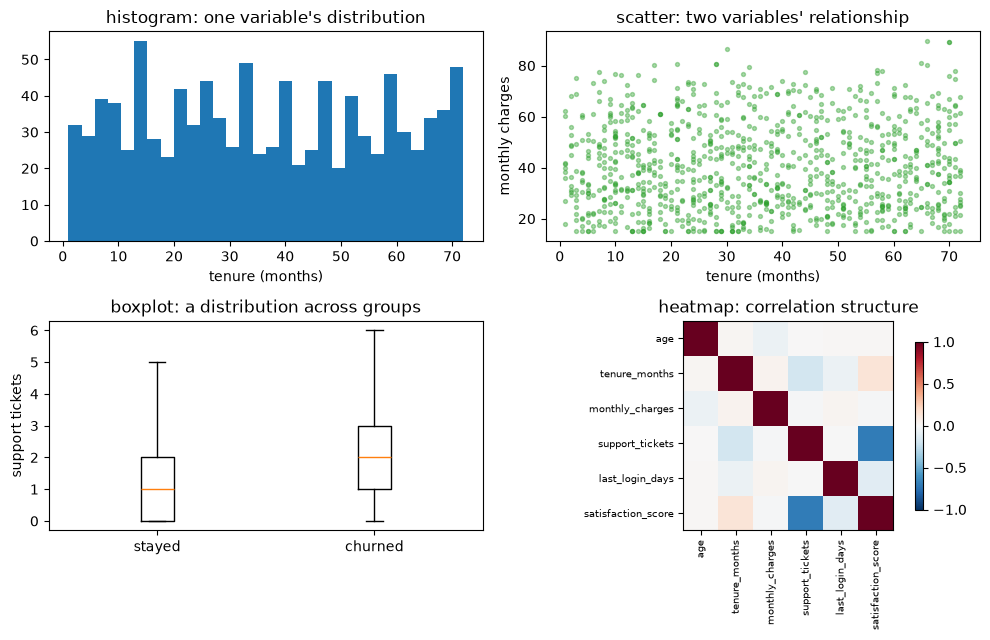

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6.5))

axes[0, 0].hist(customers["tenure_months"], bins=30, color="tab:blue")
axes[0, 0].set_title("histogram: one variable's distribution")
axes[0, 0].set_xlabel("tenure (months)")

axes[0, 1].scatter(customers["tenure_months"], customers["monthly_charges"],
                   s=8, alpha=0.4, color="tab:green")
axes[0, 1].set_title("scatter: two variables' relationship")
axes[0, 1].set_xlabel("tenure (months)")
axes[0, 1].set_ylabel("monthly charges")

churned_groups = [customers.loc[customers["churned"] == c, "support_tickets"] for c in (0, 1)]
axes[1, 0].boxplot(churned_groups, tick_labels=["stayed", "churned"])
axes[1, 0].set_title("boxplot: a distribution across groups")
axes[1, 0].set_ylabel("support tickets")

numeric = customers[["age", "tenure_months", "monthly_charges", "support_tickets",
                     "last_login_days", "satisfaction_score"]]
im = axes[1, 1].imshow(numeric.corr(), cmap="RdBu_r", vmin=-1, vmax=1)
axes[1, 1].set_xticks(range(len(numeric.columns)))
axes[1, 1].set_xticklabels(numeric.columns, rotation=90, fontsize=7)
axes[1, 1].set_yticks(range(len(numeric.columns)))
axes[1, 1].set_yticklabels(numeric.columns, fontsize=7)
axes[1, 1].set_title("heatmap: correlation structure")
fig.colorbar(im, ax=axes[1, 1], shrink=0.8)

fig.tight_layout()
plt.show()

**seaborn** sits on top of matplotlib and understands DataFrames directly: it takes column *names* and a
`data=` frame, handles the grouping, and labels the axes itself. The same boxplot, with the grouping done
for you:

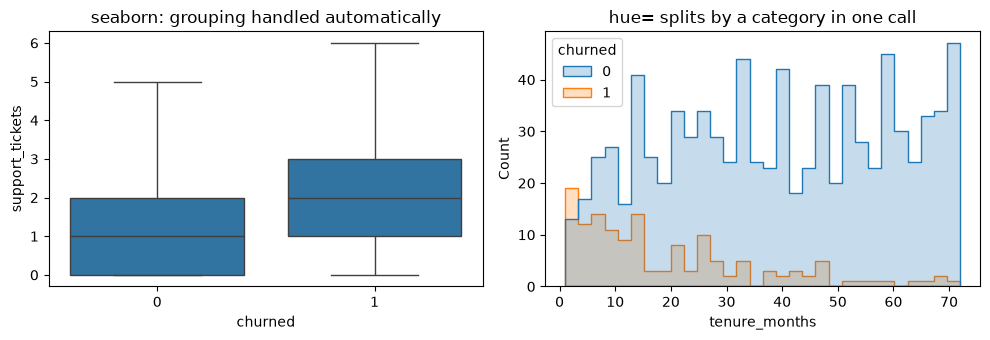

In [35]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

sns.boxplot(data=customers, x="churned", y="support_tickets", ax=axes[0])
axes[0].set_title("seaborn: grouping handled automatically")

sns.histplot(data=customers, x="tenure_months", hue="churned", bins=30,
             element="step", ax=axes[1])
axes[1].set_title("hue= splits by a category in one call")

fig.tight_layout()
plt.show()

Both panels already say something: churners raise more support tickets, and churn is concentrated among
short-tenure customers. That is Chapter 4's job done properly; here it is only evidence that a plot answers
questions a `describe()` table does not.

### 3.7 The scikit-learn Estimator API

scikit-learn's real contribution is not its algorithms — it is that all of them obey **one interface**. Once
you know the four methods, every model in Chapters 11–21 is already familiar.

| Method | Present on | Does |
|---|---|---|
| `.fit(X, y)` | Everything | Learns from data. Returns `self`, so it chains |
| `.predict(X)` | Predictors | Produces a prediction per row |
| `.transform(X)` | Transformers | Produces a modified `X` |
| `.fit_transform(X)` | Transformers | `fit` then `transform`, usually faster than both |
| `.score(X, y)` | Predictors | A default metric — R² for regressors, accuracy for classifiers |
| `.predict_proba(X)` | Most classifiers | Class probabilities rather than labels (8.6) |

Objects come in three kinds:

| Kind | Has | Example |
|---|---|---|
| **Transformer** | `fit`, `transform` | `StandardScaler`, `SimpleImputer`, `PCA` |
| **Predictor** | `fit`, `predict` | `LinearRegression`, `RandomForestClassifier` |
| **Meta-estimator** | Wraps others | `Pipeline`, `GridSearchCV`, `BaggingClassifier` |

In [36]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_bc, y_bc = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X_bc, y_bc, test_size=0.25, stratify=y_bc, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # LEARN the means/stds, then apply
X_test_scaled = scaler.transform(X_test)          # APPLY the training statistics - never refit

print("train mean ~0:", X_train_scaled.mean(axis=0)[:3].round(6))
print("train std  ~1:", X_train_scaled.std(axis=0)[:3].round(6))
print("test mean not exactly 0:", X_test_scaled.mean(axis=0)[:3].round(3))   # correct, and expected

train mean ~0: [-0.  0. -0.]
train std  ~1: [1. 1. 1.]
test mean not exactly 0: [ 0.059 -0.005  0.062]


The last line is the whole discipline in one number. The test set's scaled mean is *not* zero, because the
scaler was fitted on training data only. If it were exactly zero, the test set would have influenced the
transformation — which is leakage (22.7). 5.1 and 6.8 return to this repeatedly.

#### 3.7.1 The trailing-underscore convention

Anything learned during `fit()` gets a trailing underscore. This is how you tell an input you supplied from
an output the fitting produced — the parameter/hyperparameter distinction of 1.4, made visible in the API.

In [37]:
learned = [a for a in dir(scaler) if a.endswith("_") and not a.startswith("_")]
print("learned attributes:", learned)
print("\nmean_ (first 3):", scaler.mean_[:3].round(3))
print("hyperparameters:", scaler.get_params())   # what WE set

learned attributes: ['mean_', 'n_features_in_', 'n_samples_seen_', 'scale_', 'var_']

mean_ (first 3): [14.075 19.295 91.593]
hyperparameters: {'copy': True, 'with_mean': True, 'with_std': True}


#### 3.7.2 The interface is the point

Because every predictor exposes the same three methods, swapping models is a one-line change. This is what
makes Chapter 23's search over model families possible at all.

In [38]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

models = {
    "dummy": DummyClassifier(strategy="most_frequent"),
    "logistic": LogisticRegression(max_iter=5000),
    "knn": KNeighborsClassifier(),
    "forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)                       # identical call
    print(f"{name:<10} test accuracy {model.score(X_test_scaled, y_test):.3f}")

dummy      test accuracy 0.629
logistic   test accuracy 0.986


knn        test accuracy 0.979


forest     test accuracy 0.958


Four genuinely different algorithms, one loop, no special cases. Note the dummy baseline sitting at the
bottom — 1.6's argument, now a routine line of code.

#### 3.7.3 Pipelines, briefly

A `Pipeline` chains transformers and a final estimator into a single object that itself obeys the estimator
API. It exists to make the fit-on-train-only rule structural rather than a thing you remember. Chapter 23
covers it properly.

In [39]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000)),
])

pipe.fit(X_train, y_train)   # raw X: the scaler is fitted inside, on training data only
print("pipeline test accuracy:", round(pipe.score(X_test, y_test), 3))
print("steps:", list(pipe.named_steps))

pipeline test accuracy: 0.986
steps: ['scale', 'model']


### 3.8 Reproducibility: `random_state`, seeds and determinism

A result you cannot reproduce is not a result. Every stochastic operation in scikit-learn takes a
`random_state`, and this material sets it everywhere (§0.7 of the index).

In [40]:
X_small, y_small = X_bc[:200], y_bc[:200]

unseeded = [train_test_split(X_small, y_small, test_size=0.3)[3][:5] for _ in range(2)]
seeded = [train_test_split(X_small, y_small, test_size=0.3, random_state=0)[3][:5] for _ in range(2)]

print("no random_state, run 1:", unseeded[0])
print("no random_state, run 2:", unseeded[1], "  <- different split")
print("random_state=0, run 1 :", seeded[0])
print("random_state=0, run 2 :", seeded[1], "  <- identical")

no random_state, run 1: [0 1 1 1 0]
no random_state, run 2: [0 1 1 1 1]   <- different split
random_state=0, run 1 : [0 1 1 1 0]
random_state=0, run 2 : [0 1 1 1 0]   <- identical


**`int` versus a stateful instance — they behave differently.** An integer is a *fixed* seed: every call
that receives it restarts from the same state, so two estimators given `random_state=42` make correlated
random choices. A `RandomState` **instance** carries its state forward, so successive calls consume
different draws.

| Passed to `random_state` | Behaviour | Use when |
|---|---|---|
| `int` | Reseeds identically at every call | You want exact reproducibility across runs — the default here |
| `np.random.RandomState(...)` | Advances; each call differs | You want independent randomness within one reproducible run |
| `None` | Fresh entropy every call | Never, in work you intend to report |

Note the asymmetry with 3.2.2: scikit-learn's `random_state` accepts `int`, a legacy `RandomState`
instance, or `None` — it does **not** accept NumPy's modern `Generator`, even though `Generator` is the
right choice for your own NumPy code. Mixing the two APIs in one project is normal and slightly annoying.

In [41]:
shared_int = 7
a1 = train_test_split(X_small, y_small, test_size=0.3, random_state=shared_int)[3][:5]
a2 = train_test_split(X_small, y_small, test_size=0.3, random_state=shared_int)[3][:5]
print("int seed reused        :", a1, a2, "-> identical")

shared_state = np.random.RandomState(7)   # legacy object, but the one sklearn accepts
b1 = train_test_split(X_small, y_small, test_size=0.3, random_state=shared_state)[3][:5]
b2 = train_test_split(X_small, y_small, test_size=0.3, random_state=shared_state)[3][:5]
print("RandomState reused     :", b1, b2, "-> different, the instance advanced")

int seed reused        : [0 1 0 0 1] [0 1 0 0 1] -> identical
RandomState reused     : [0 1 0 0 1] [1 0 1 0 0] -> different, the instance advanced


In [42]:
# A modern Generator is rejected outright - worth seeing once so the error is recognizable.
try:
    train_test_split(X_small, y_small, test_size=0.3, random_state=np.random.default_rng(7))
except ValueError as e:
    print("ValueError:", str(e)[:95])

ValueError: The 'random_state' parameter of train_test_split must be an int in the range [0, 4294967295], a


**Common mistake — assuming a seed makes everything deterministic.** It fixes the *algorithm's* randomness
and nothing else. These remain sources of run-to-run variation:

| Source | Why it varies | Mitigation |
|---|---|---|
| Multi-threaded float summation | Addition is not associative; thread scheduling changes the order | `n_jobs=1`, or accept last-digit noise |
| BLAS thread count | Different machines parallelize differently | Pin `OMP_NUM_THREADS` if bit-exactness is needed |
| Library version changes | Default hyperparameters and algorithms change between releases | Lock dependencies — `uv.lock` here |
| Hardware (CPU vs GPU, AVX levels) | Different instruction sets round differently | Compare with a tolerance, not `==` |
| Python `hash()` randomization | Set/dict iteration order across processes | `PYTHONHASHSEED`, or sort explicitly |

The practical version of this rule: compare floating-point results with `np.allclose`, never `==`, and pin
your environment if a number has to be identical rather than merely equivalent.

### 3.9 In Practice

#### 3.9.1 A worked case: the churn report nobody can argue with

The request: *"Which customer segments are we losing, and is it worth acting on?"* Someone wants a table
they can take to a meeting. This is the most common piece of work in a data role, it comes before any
model, and doing it correctly is entirely a pandas exercise.

The trap is that `data/customers.csv` will happily produce a **wrong** table, silently, if loaded and
grouped naively. Work through it properly.

**Step 1 — load, and repair what `info()` exposed (3.3.1).**

In [43]:
raw = pd.read_csv("data/customers.csv")
print("loaded:", raw.shape)

clean = (
    raw
    .drop_duplicates()                                    # 12 exact duplicate rows from a double-run merge
    .assign(
        total_charges=lambda d: pd.to_numeric(d["total_charges"], errors="coerce"),
        # strip + lower gets "M"/"Male "/"male" down to "m"/"male" - still two labels
        # for one value, so map the survivors onto a canonical pair.
        gender=lambda d: (d["gender"].str.strip().str.lower()
                          .replace({"male": "m", "female": "f"})),
    )
)

print("after dedup:", clean.shape, f"({len(raw) - len(clean)} duplicate rows removed)")
print("gender values now:", sorted(clean["gender"].dropna().unique()))   # ['f', 'm'] - six spellings -> two

loaded: (1012, 14)
after dedup: (1000, 14) (12 duplicate rows removed)
gender values now: ['f', 'm']


**Step 2 — deal with the impossible values before they reach a mean.** The `age` column contains entries
that are not merely extreme but impossible, and a `groupby` would fold them straight into the averages.

In [44]:
implausible = clean["age"].isna() | (clean["age"] < 16) | (clean["age"] > 100)
print("implausible ages:", clean.loc[implausible, "age"].dropna().tolist())

clean = clean.assign(age=clean["age"].where(~implausible))   # replace with NaN, do not drop the customer
print("age range now:", clean["age"].min(), "-", clean["age"].max())
print("age nulls    :", clean["age"].isna().sum())

implausible ages: [199.0, 1.0, 150.0, 0.0]
age range now: 18.0 - 76.0
age nulls    : 63


Replacing with `NaN` rather than dropping the row is deliberate: the customer's *other* fields are fine, and
a churn report that quietly discards customers is a biased churn report. 5.3 covers the choice properly.

**Step 3 — the segment table.** A rate alone is not decision-ready. A segment with a 50% churn rate and four
customers in it is noise, so the count belongs in the table next to the rate.

In [45]:
segments = (
    clean.groupby("plan")
    .agg(
        customers=("customer_id", "count"),
        churned=("churned", "sum"),
        churn_rate=("churned", "mean"),
        avg_monthly=("monthly_charges", "mean"),
        avg_tenure=("tenure_months", "mean"),
    )
    .assign(monthly_revenue_at_risk=lambda d: d["churned"] * d["avg_monthly"])
    .round(2)
    .sort_values("monthly_revenue_at_risk", ascending=False)
)

print(segments)

          customers  churned  churn_rate  avg_monthly  avg_tenure  monthly_revenue_at_risk
plan                                                                                      
Standard        338       50        0.15        45.72       37.17                  2285.96
Premium         205       30        0.15        64.89       38.25                  1946.75
Basic           457       61        0.13        25.64       35.16                  1563.98


The last column is what converts a statistic into a decision. Churn *rate* ranks the segments one way;
revenue at risk ranks them by how much money is actually leaving, which is the question the business asked.

**Step 4 — check that a difference is real before reporting it.** 2.8.3's warning applies directly: with
segments this size, an apparent gap may be sampling noise.

In [46]:
from scipy.stats import chi2_contingency

table = pd.crosstab(clean["plan"], clean["churned"])
chi2, p_value, _, _ = chi2_contingency(table)

print(table)
print(f"\nchi-square p-value: {p_value:.4f}")
print("->", "plan and churn are associated" if p_value < 0.05
      else "no detectable association - do NOT report a difference")

churned     0   1
plan             
Basic     396  61
Premium   175  30
Standard  288  50

chi-square p-value: 0.8205
-> no detectable association - do NOT report a difference


**Step 5 — the deliverable.** Two sentences and the table above:

> *After removing 12 duplicate rows and blanking 4 impossible ages, churn is 14.1% overall. Standard plan
> carries the most revenue at risk (₹2,286/month), but a chi-square test on plan vs. churn gives p = 0.82,
> so the rate differences between plans are indistinguishable from sampling noise — plan is not, on this
> data, a segment worth targeting. Tenure and support tickets do separate churners (3.6): customers with 3+
> tickets and under a year of tenure churn at 67.9% against a 14.1% base rate. That is where the next hour
> should go.*

That last sentence is the value of the exercise. The honest finding was *negative*, and reporting it stops
a retention campaign from being aimed at the wrong thing.

#### 3.9.2 When to reach for which tool

| Task | Tool | Not |
|---|---|---|
| Numerical work on a homogeneous array | NumPy | pandas — the per-column overhead buys nothing |
| Named columns, mixed types, missing values | pandas | NumPy — it has no notion of a column name |
| Joining, grouping, reshaping | pandas | Hand-written loops |
| Element-wise maths over millions of values | NumPy vectorization | `.apply()`, `.iterrows()`, Python loops |
| Any `fit`/`transform` step | scikit-learn transformers | pandas, if the step must be reproduced at inference |
| Quick look at a distribution | matplotlib / seaborn | `describe()` alone — 2.8.2 showed why |
| A transformation that must run identically in production | A scikit-learn `Pipeline` (3.7.3) | Notebook cells that must be re-run in order |

The fifth and last rows are the ones that separate exploratory code from production code. A pandas
expression that cleans training data is fine in a notebook and a liability in a serving path, because
nothing guarantees the same expression runs the same way on one incoming row. A fitted transformer carries
its learned state with it; an ad-hoc pandas chain does not.

#### 3.9.3 What goes wrong in production

| Failure | What it looks like | Where it is handled |
|---|---|---|
| **dtype drift** | A column arrives as text one day because one row had a blank; the model silently sees a different feature | 5.4 |
| **Unseen category** | A city not present at training time; a one-hot encoder errors or, worse, silently drops it | 6.2 |
| **Index misalignment** | Two pandas objects combined by *index*, not position, producing `NaN` rows nobody notices | Below |
| **Column reordering** | An upstream change reorders columns; a NumPy-array model reads feature 3 as feature 5 | 3.7.3 pipelines |
| **Silent row multiplication** | A join against a non-unique key duplicates rows (3.5.2) | 3.5.2 |
| **Memory blowup** | A merge or a one-hot expansion that fits in a notebook and not in a container | 6.2 |

Index misalignment deserves a demonstration because it produces wrong numbers with no error at all.

In [47]:
left = pd.Series([1.0, 2.0, 3.0], index=[0, 1, 2])
right = pd.Series([10.0, 20.0, 30.0], index=[1, 2, 3])   # a filtered frame keeps its ORIGINAL index

print("pandas aligns on the INDEX, not position:")
print(left + right)   # NaN wherever the indices do not overlap

pandas aligns on the INDEX, not position:
0     NaN
1    12.0
2    23.0
3     NaN
dtype: float64


In [48]:
# The fix: align explicitly, or drop to NumPy where positional semantics are what you meant.
print("positional (via .to_numpy()):", left.to_numpy() + right.to_numpy())
print("or reset the index first    :", (left + right.reset_index(drop=True)).tolist())

positional (via .to_numpy()): [11. 22. 33.]
or reset the index first    : [11.0, 22.0, 33.0]


This is the single most common way a pandas cleaning step produces silently wrong features: a filtered
subset keeps its original index, gets combined with a freshly built column that starts at 0, and the
overlap becomes `NaN` — which an imputer then cheerfully fills with a median. The model trains on
fabricated values and nothing anywhere raises an error.

The defence, and the reason Chapter 23 insists on it: **express every training-time transformation as a
fitted scikit-learn transformer inside a `Pipeline`**, so the identical, stateful operation runs at
inference time. Ad-hoc pandas is for exploring; pipelines are for shipping.

In [49]:
# --- 3. The Python Machine Learning Stack — scratch cell ---# Experiments for this chapter. Promote anything worth keeping into the# relevant section as a proper example cell.